In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

In [27]:
# Read Clustered Data

df = pd.read_pickle(
    'G:/Mohanraj D_OFFICIAL/GUVI (Data Analyst)/Mini-Projects/PatrolIQ/engineered_chicago_crime_data.pkl'
)

df.head()

,Date,Primary Type,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,Year,...,Hour,Is_Weekend,Season,Lat_bin,Lon_bin,Crime_Severity_Score,Location_Desc_freq,Primary Type_freq,Latitude_Norm,Longitude_Norm
0,2016-12-31 23:59:00,30,3,0,0,1651,16,41,76,2016,...,23,1,3,"(41.753, 42.023]","(-87.941, -87.733]",1.0,0.000122,0.216753,1.470472,-3.629450
1,2016-12-31 23:58:00,2,135,0,0,522,5,34,49,2016,...,23,1,3,"(41.482, 41.753]","(-87.733, -87.525]",3.0,0.163276,0.178889,-1.663659,0.753301
2,2016-12-31 23:55:00,16,135,1,0,1932,19,32,6,2016,...,23,1,3,"(41.753, 42.023]","(-87.733, -87.525]",1.0,0.163276,0.001666,1.042028,0.117016
3,2016-12-31 23:55:00,2,99,0,1,111,1,42,32,2016,...,23,1,3,"(41.753, 42.023]","(-87.733, -87.525]",3.0,0.003961,0.178889,0.497632,0.727418
4,2016-12-31 23:54:00,6,135,0,1,623,6,6,69,2016,...,23,1,3,"(41.482, 41.753]","(-87.733, -87.525]",2.0,0.163276,0.111719,-0.964830,0.817709


In [28]:
df.columns

Index(['Date', 'Primary Type', 'Location Description', 'Arrest', 'Domestic',
       'Beat', 'District', 'Ward', 'Community Area', 'Year', 'Latitude',
       'Longitude', 'Month', 'Day_of_Week', 'Hour', 'Is_Weekend', 'Season',
       'Lat_bin', 'Lon_bin', 'Crime_Severity_Score', 'Location_Desc_freq',
       'Primary Type_freq', 'Latitude_Norm', 'Longitude_Norm'],
      dtype='object')

In [29]:
df['Date'] = pd.to_datetime(
    df['Date']
)

In [25]:
df.columns

Index(['Latitude', 'Longitude', 'Hour', 'Month', 'Crime_Severity_Score',
       'Geo_Cluster'],
      dtype='object')

In [30]:
df['Day_of_Week'] = (

    df['Date']
    .dt.day_name()
)

In [31]:
def get_season(month):

    if month in [12, 1, 2]:
        return 'Winter'

    elif month in [3, 4, 5]:
        return 'Spring'

    elif month in [6, 7, 8]:
        return 'Summer'

    else:
        return 'Fall'


df['Season'] = df['Month'].apply(
    get_season
)

In [32]:
geo_features = [

    'Latitude',

    'Longitude',

    'Hour',

    'Month',

    'Crime_Severity_Score'
]

In [33]:
geo_df = df[geo_features].copy()

geo_df.dropna(inplace=True)

In [34]:
scaler_geo = StandardScaler()

X_geo_scaled = scaler_geo.fit_transform(
    geo_df
)

In [35]:
# ELBOW METHOD

inertia = []

K = range(2, 11)

for k in K:

    model = KMeans(

        n_clusters=k,

        random_state=42
    )

    model.fit(X_geo_scaled)

    inertia.append(
        model.inertia_
    )

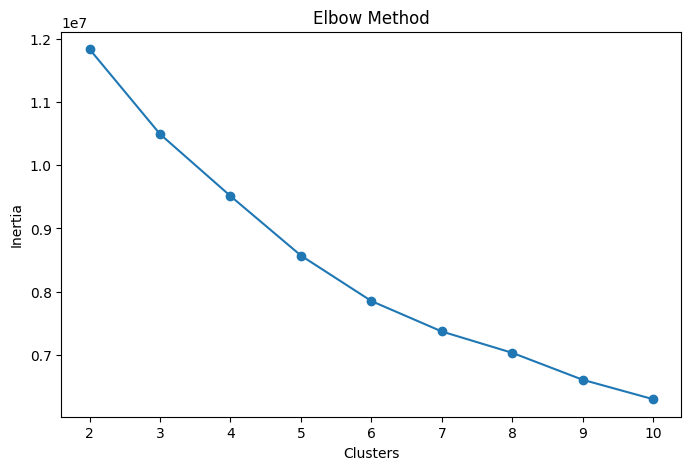

In [36]:
# PLOT ELBOW CURVE

plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o'
)

plt.xlabel("Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [37]:
# TRAIN KMEANS

kmeans_geo = KMeans(

    n_clusters=7,

    random_state=42
)

geo_df['Geo_Cluster'] = (

    kmeans_geo.fit_predict(
        X_geo_scaled
    )
)

In [38]:
# SILHOUETTE SCORE

geo_silhouette = silhouette_score(

    X_geo_scaled,

    geo_df['Geo_Cluster'],

    sample_size=10000,

    random_state=42
)

print(
    geo_silhouette
)

0.17597788603022838


In [39]:
# DB SCORE

geo_db_score = davies_bouldin_score(

    X_geo_scaled,

    geo_df['Geo_Cluster']
)

print(
    geo_db_score
)

1.4795657769770234


In [40]:
# CREATE MLFLOW EXPERIMENT

mlflow.set_experiment(
    "K-Means_Clustering"
)

<Experiment: artifact_location=('file:g:/Mohanraj D_OFFICIAL/GUVI (Data '
 'Analyst)/Mini-Projects/PatrolIQ/mlruns/2'), creation_time=1779630359601, experiment_id='2', last_update_time=1779630359601, lifecycle_stage='active', name='K-Means_Clustering', tags={}, trace_location=None, workspace='default'>

In [41]:
# LOG MODEL INTO MLFLOW

with mlflow.start_run(
    run_name="KMeans_Run_1"
):

    mlflow.log_param(
        "algorithm",
        "KMeans"
    )

    mlflow.log_param(
        "n_clusters",
        7
    )

    mlflow.log_param(
        "random_state",
        42
    )

    mlflow.log_metric(
        "silhouette_score",
        geo_silhouette
    )

    mlflow.log_metric(
        "davies_bouldin_score",
        geo_db_score
    )

    mlflow.log_metric(
        "inertia",
        kmeans_geo.inertia_
    )

    mlflow.sklearn.log_model(
        kmeans_geo,
        "KMeans_Model"
    )

print(
    "KMeans Logged Successfully"
)

2026/05/25 13:15:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 13:15:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KMeans Logged Successfully


In [42]:
# DBSCAN MODEL

geo_sample = geo_df.sample(
    50000,
    random_state=42
)

X_geo_sample = scaler_geo.fit_transform(
    geo_sample[geo_features]
)

dbscan_geo = DBSCAN(
    eps=0.5,
    min_samples=10
)

geo_sample['DBSCAN_Cluster'] = (

    dbscan_geo.fit_predict(
        X_geo_sample
    )
)

In [43]:
# DBSCAN METRIC

dbscan_silhouette = silhouette_score(

    X_geo_sample,

    geo_sample['DBSCAN_Cluster'],

    sample_size=5000
)

print(
    dbscan_silhouette
)

-0.03667696685037588


In [44]:
# LOG DBSCAN

mlflow.set_experiment(
    "DBSCAN_Clustering"
)

with mlflow.start_run(
    run_name="DBSCAN_Run_1"
):

    mlflow.log_param(
        "algorithm",
        "DBSCAN"
    )

    mlflow.log_param(
        "eps",
        0.5
    )

    mlflow.log_param(
        "min_samples",
        10
    )

    mlflow.log_metric(
        "silhouette_score",
        dbscan_silhouette
    )

print(
    "DBSCAN Logged"
)

DBSCAN Logged


In [45]:
# HIERARCHICAL MODEL

hier_sample = geo_df.sample(
    5000,
    random_state=42
)

X_hier = scaler_geo.fit_transform(
    hier_sample[geo_features]
)

hc_geo = AgglomerativeClustering(
    n_clusters=7,
    linkage='ward'
)

hier_sample['HC_Cluster'] = (

    hc_geo.fit_predict(
        X_hier
    )
)

In [46]:
# HIERARCHICAL METRIC

hc_silhouette = silhouette_score(

    X_hier,

    hier_sample['HC_Cluster']
)

print(
    hc_silhouette
)

0.12328420768182932


In [47]:
# LOG HIERARCHICAL MODEL

mlflow.set_experiment(
    "Hierarchical_Clustering"
)

with mlflow.start_run(
    run_name="Hierarchical_Run_1"
):

    mlflow.log_param(
        "algorithm",
        "Hierarchical"
    )

    mlflow.log_param(
        "linkage",
        "ward"
    )

    mlflow.log_param(
        "n_clusters",
        7
    )

    mlflow.log_metric(
        "silhouette_score",
        hc_silhouette
    )

print(
    "Hierarchical Logged"
)

Hierarchical Logged


In [48]:
# TEMPORAL CLUSTERING

le_day = LabelEncoder()

df['Day_Encoded'] = (

    le_day.fit_transform(
        df['Day_of_Week']
    )
)

le_season = LabelEncoder()

df['Season_Encoded'] = (

    le_season.fit_transform(
        df['Season']
    )
)

In [49]:
# TEMPORAL FEATURES

temp_features = [

    'Hour',

    'Day_Encoded',

    'Month',

    'Season_Encoded'
]

In [50]:
temp_df = df[temp_features].copy()

temp_df.dropna(inplace=True)

In [51]:
scaler_temp = StandardScaler()

X_temp_scaled = scaler_temp.fit_transform(
    temp_df
)

In [52]:
kmeans_temp = KMeans(

    n_clusters=5,

    random_state=42
)

temp_df['Temporal_Cluster'] = (

    kmeans_temp.fit_predict(
        X_temp_scaled
    )
)

In [53]:
temp_silhouette = silhouette_score(

    X_temp_scaled,

    temp_df['Temporal_Cluster'],

    sample_size=10000,

    random_state=42
)

print(
    temp_silhouette
)

0.2810153892383645


In [54]:
# LOG TEMPORAL MODEL

mlflow.set_experiment(
    "Temporal_Clustering"
)

with mlflow.start_run(
    run_name="Temporal_Run_1"
):

    mlflow.log_param(
        "algorithm",
        "KMeans"
    )

    mlflow.log_param(
        "n_clusters",
        5
    )

    mlflow.log_metric(
        "silhouette_score",
        temp_silhouette
    )

print(
    "Temporal Logged"
)

Temporal Logged


In [55]:
# MODEL COMPARISON

comparison = pd.DataFrame({

    'Model': [

        'KMeans',

        'DBSCAN',

        'Hierarchical',

        'Temporal KMeans'
    ],

    'Silhouette Score': [

        geo_silhouette,

        dbscan_silhouette,

        hc_silhouette,

        temp_silhouette
    ]
})

comparison

,Model,Silhouette Score
0,KMeans,0.175978
1,DBSCAN,-0.036677
2,Hierarchical,0.123284
3,Temporal KMeans,0.281015


In [56]:
# SAVE FILES

comparison.to_csv(
    'model_comparison.csv',
    index=False
)

geo_df.to_pickle(
    'Geographic_clusters.pkl'
)

temp_df.to_pickle(
    'temporal_clusters.pkl'
)

print(
    "All Files Saved"
)

All Files Saved


In [57]:
geo_features = [

    'Latitude',

    'Longitude',

    'Hour',

    'Month',

    'Crime_Severity_Score'
]

In [58]:
geo_df = df[geo_features].copy()

geo_df.dropna(inplace=True)

In [59]:
scaler_geo = StandardScaler()

X_geo_scaled = scaler_geo.fit_transform(
    geo_df
)

In [60]:
kmeans_geo = KMeans(

    n_clusters=7,

    random_state=42
)

geo_df['Geo_Cluster'] = (

    kmeans_geo.fit_predict(
        X_geo_scaled
    )
)

In [61]:
geo_silhouette = silhouette_score(

    X_geo_scaled,

    geo_df['Geo_Cluster'],

    sample_size=10000,

    random_state=42
)

print(
    geo_silhouette
)

0.17597788603022838


In [62]:
mlflow.set_experiment(
    "K-Means_Clustering"
)

<Experiment: artifact_location=('file:g:/Mohanraj D_OFFICIAL/GUVI (Data '
 'Analyst)/Mini-Projects/PatrolIQ/mlruns/2'), creation_time=1779630359601, experiment_id='2', last_update_time=1779630359601, lifecycle_stage='active', name='K-Means_Clustering', tags={}, trace_location=None, workspace='default'>

In [63]:
with mlflow.start_run(
    run_name="KMeans_Run_1"
):

    mlflow.log_param(
        "algorithm",
        "KMeans"
    )

    mlflow.log_param(
        "n_clusters",
        7
    )

    mlflow.log_metric(
        "silhouette_score",
        geo_silhouette
    )

    mlflow.log_metric(
        "inertia",
        kmeans_geo.inertia_
    )

    mlflow.sklearn.log_model(
        kmeans_geo,
        "KMeans_Model"
    )

print(
    "Experiment Logged Successfully"
)

2026/05/25 13:29:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 13:29:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Experiment Logged Successfully


In [65]:
import pandas as pd

import mlflow
import mlflow.sklearn

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# TRACKING URI
mlflow.set_tracking_uri(
    "file:./mlruns"
)

# LOAD DATA
df = pd.read_pickle(
    'G:/Mohanraj D_OFFICIAL/GUVI (Data Analyst)/Mini-Projects/PatrolIQ/engineered_chicago_crime_data.pkl'
)

# FEATURES
geo_features = [

    'Latitude',

    'Longitude',

    'Hour',

    'Month',

    'Crime_Severity_Score'
]

# DATAFRAME
geo_df = df[geo_features].copy()

geo_df.dropna(inplace=True)

# SCALING
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    geo_df
)

# MODEL
kmeans = KMeans(
    n_clusters=7,
    random_state=42
)

geo_df['Cluster'] = kmeans.fit_predict(
    X_scaled
)

# METRIC
sil_score = silhouette_score(
    X_scaled,
    geo_df['Cluster'],
    sample_size=10000,
    random_state=42
)

# EXPERIMENT
mlflow.set_experiment(
    "KMeans_Clustering"
)

# LOGGING
with mlflow.start_run():

    mlflow.log_param(
        "n_clusters",
        7
    )

    mlflow.log_metric(
        "silhouette_score",
        sil_score
    )

    mlflow.log_metric(
        "inertia",
        kmeans.inertia_
    )

    mlflow.sklearn.log_model(
        kmeans,
        "KMeans_Model"
    )

print(
    "MLflow Logged Successfully"
)

Traceback (most recent call last):
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r

MLflow Logged Successfully


In [66]:
import mlflow

mlflow.set_tracking_uri("file:./mlruns")

mlflow.set_experiment("TEST_EXPERIMENT")

with mlflow.start_run():

    mlflow.log_param(
        "test_param",
        100
    )

    mlflow.log_metric(
        "test_metric",
        0.95
    )

print("SUCCESS")

Traceback (most recent call last):
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r

SUCCESS


In [67]:
import pandas as pd

import mlflow
import mlflow.sklearn

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# =====================================================
# TRACKING URI
# =====================================================

mlflow.set_tracking_uri(
    "file:./mlruns"
)

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_pickle(
    'G:/Mohanraj D_OFFICIAL/GUVI (Data Analyst)/Mini-Projects/PatrolIQ/engineered_chicago_crime_data.pkl'
)

# =====================================================
# FEATURES
# =====================================================

geo_features = [

    'Latitude',

    'Longitude',

    'Hour',

    'Month',

    'Crime_Severity_Score'
]

# =====================================================
# DATAFRAME
# =====================================================

geo_df = df[geo_features].copy()

geo_df.dropna(inplace=True)

# =====================================================
# SCALING
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    geo_df
)

# =====================================================
# MODEL
# =====================================================

kmeans = KMeans(
    n_clusters=7,
    random_state=42
)

clusters = kmeans.fit_predict(
    X_scaled
)

geo_df['Cluster'] = clusters

# =====================================================
# METRIC
# =====================================================

sil_score = silhouette_score(
    X_scaled,
    clusters,
    sample_size=5000,
    random_state=42
)

print(
    "Silhouette Score:",
    sil_score
)

# =====================================================
# CREATE EXPERIMENT
# =====================================================

mlflow.set_experiment(
    "KMeans_Clustering"
)

# =====================================================
# START RUN
# =====================================================

with mlflow.start_run(
    run_name="KMeans_Run_1"
):

    # PARAMETERS
    mlflow.log_param(
        "algorithm",
        "KMeans"
    )

    mlflow.log_param(
        "n_clusters",
        7
    )

    # METRICS
    mlflow.log_metric(
        "silhouette_score",
        float(sil_score)
    )

    mlflow.log_metric(
        "inertia",
        float(kmeans.inertia_)
    )

    # TAG
    mlflow.set_tag(
        "Project",
        "PatrolIQ"
    )

    # MODEL
    mlflow.sklearn.log_model(
        sk_model=kmeans,
        artifact_path="KMeans_Model"
    )

print(
    "RUN LOGGED SUCCESSFULLY"
)

Traceback (most recent call last):
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r

Silhouette Score: 0.17445205458764682


2026/05/25 13:47:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RUN LOGGED SUCCESSFULLY


In [68]:
import pandas as pd

import mlflow
import mlflow.sklearn

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)


# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_pickle(
    'G:/Mohanraj D_OFFICIAL/GUVI (Data Analyst)/Mini-Projects/PatrolIQ/engineered_chicago_crime_data.pkl'
)

# =====================================================
# FEATURES
# =====================================================

geo_features = [

    'Latitude',

    'Longitude',

    'Hour',

    'Month',

    'Crime_Severity_Score'
]

# =====================================================
# DATAFRAME
# =====================================================

geo_df = df[geo_features].copy()

geo_df.dropna(inplace=True)

# =====================================================
# SCALE DATA
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    geo_df
)

# =====================================================
# CREATE EXPERIMENT
# =====================================================

mlflow.set_experiment(
    "KMeans_Clustering"
)

# =====================================================
# LOOP FOR MULTIPLE K VALUES
# =====================================================

k_values = [5, 6, 7, 8, 9, 10]

for k in k_values:

    print(f"\nRunning KMeans for K = {k}")

    # MODEL
    kmeans = KMeans(

        n_clusters=k,

        random_state=42
    )

    clusters = kmeans.fit_predict(
        X_scaled
    )

    # METRICS
    sil_score = silhouette_score(

        X_scaled,

        clusters,

        sample_size=5000,

        random_state=42
    )

    db_score = davies_bouldin_score(

        X_scaled,

        clusters
    )

    inertia = kmeans.inertia_

    print(
        "Silhouette Score:",
        sil_score
    )

    # =================================================
    # MLFLOW RUN
    # =================================================

    with mlflow.start_run(
        run_name=f"KMeans_K_{k}"
    ):

        # PARAMETERS
        mlflow.log_param(
            "algorithm",
            "KMeans"
        )

        mlflow.log_param(
            "n_clusters",
            k
        )

        mlflow.log_param(
            "random_state",
            42
        )

        # METRICS
        mlflow.log_metric(
            "silhouette_score",
            float(sil_score)
        )

        mlflow.log_metric(
            "davies_bouldin_score",
            float(db_score)
        )

        mlflow.log_metric(
            "inertia",
            float(inertia)
        )

        # TAGS
        mlflow.set_tag(
            "Project",
            "PatrolIQ"
        )

        # MODEL
        mlflow.sklearn.log_model(
            sk_model=kmeans,
            artifact_path=f"KMeans_Model_K_{k}"
        )

    print(
        f"K={k} Logged Successfully"
    )

print(
    "\nALL KMEANS RUNS COMPLETED"
)

Traceback (most recent call last):
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r


Running KMeans for K = 5


2026/05/25 13:51:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Silhouette Score: 0.17823548953581497


2026/05/25 13:51:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

Silhouette Score: 0.17196470484116008
K=8 Logged Successfully

Running KMeans for K = 9


2026/05/25 13:52:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 13:52:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Silhouette Score: 0.17744835128785552
K=9 Logged Successfully

Running KMeans for K = 10


2026/05/25 13:52:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 13:52:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Silhouette Score: 0.17967714172224855
K=10 Logged Successfully

ALL KMEANS RUNS COMPLETED


In [70]:
mlflow.sklearn.log_model(
    sk_model=dbscan,
    artifact_path=f"DBSCAN_Model_eps_{str(eps).replace('.', '_')}"
)

2026/05/25 13:55:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 13:55:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/25 13:55:30 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


In [72]:
import pandas as pd

import mlflow
import mlflow.sklearn

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)



# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_pickle(
    'G:/Mohanraj D_OFFICIAL/GUVI (Data Analyst)/Mini-Projects/PatrolIQ/engineered_chicago_crime_data.pkl'
)

# =====================================================
# FEATURES
# =====================================================

geo_features = [

    'Latitude',

    'Longitude',

    'Hour',

    'Month',

    'Crime_Severity_Score'
]

# =====================================================
# CREATE DATAFRAME
# =====================================================

geo_df = df[geo_features].copy()

geo_df.dropna(inplace=True)

# =====================================================
# SAMPLE DATA
# DBSCAN IS SLOW FOR LARGE DATA
# =====================================================

geo_sample = geo_df.sample(

    50000,

    random_state=42
)

# =====================================================
# SCALE DATA
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    geo_sample
)

# =====================================================
# CREATE EXPERIMENT
# =====================================================

mlflow.set_experiment(
    "DBSCAN_Clustering"
)

# =====================================================
# DIFFERENT EPS VALUES
# =====================================================

eps_values = [0.3, 0.5, 0.7, 1.0]

for eps in eps_values:

    print(f"\nRunning DBSCAN for eps = {eps}")

    # MODEL
    dbscan = DBSCAN(

        eps=eps,

        min_samples=10
    )

    clusters = dbscan.fit_predict(
        X_scaled
    )

    # =================================================
    # REMOVE NOISE FOR METRICS
    # =================================================

    mask = clusters != -1

    X_filtered = X_scaled[mask]

    cluster_filtered = clusters[mask]

    # =================================================
    # CHECK VALID CLUSTERS
    # =================================================

    unique_clusters = len(
        set(cluster_filtered)
    )

    if unique_clusters > 1:

        sil_score = silhouette_score(

            X_filtered,

            cluster_filtered,

            sample_size=5000,

            random_state=42
        )

        db_score = davies_bouldin_score(

            X_filtered,

            cluster_filtered
        )

    else:

        sil_score = -1
        db_score = -1

    # =================================================
    # PRINT RESULTS
    # =================================================

    print(
        "Clusters Found:",
        unique_clusters
    )

    print(
        "Silhouette Score:",
        sil_score
    )

    # =================================================
    # START MLFLOW RUN
    # =================================================

    with mlflow.start_run(
        run_name=f"DBSCAN_eps_{eps}"
    ):

        # PARAMETERS
        mlflow.log_param(
            "algorithm",
            "DBSCAN"
        )

        mlflow.log_param(
            "eps",
            eps
        )

        mlflow.log_param(
            "min_samples",
            10
        )

        # METRICS
        mlflow.log_metric(
            "silhouette_score",
            float(sil_score)
        )

        mlflow.log_metric(
            "davies_bouldin_score",
            float(db_score)
        )

        mlflow.log_metric(
            "clusters_found",
            unique_clusters
        )

        # TAG
        mlflow.set_tag(
            "Project",
            "PatrolIQ"
        )

        # MODEL
        mlflow.sklearn.log_model(
            sk_model=dbscan,
            artifact_path=f"DBSCAN_Model_eps_{str(eps).replace('.', '_')}"
        )

    print(
        f"eps={eps} Logged Successfully"
    )

print(
    "\nALL DBSCAN RUNS COMPLETED"
)

Traceback (most recent call last):
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r


Running DBSCAN for eps = 0.3


2026/05/25 13:58:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 13:58:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/25 13:58:00 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Clusters Found: 445
Silhouette Score: -0.26083423743851436
eps=0.3 Logged Successfully

Running DBSCAN for eps = 0.5


2026/05/25 13:58:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 13:58:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/25 13:58:12 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Clusters Found: 13
Silhouette Score: 0.018143892914284195
eps=0.5 Logged Successfully

Running DBSCAN for eps = 0.7


2026/05/25 13:58:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 13:58:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/25 13:58:29 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Clusters Found: 5
Silhouette Score: 0.07469962429482055
eps=0.7 Logged Successfully

Running DBSCAN for eps = 1.0


2026/05/25 13:58:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 13:58:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/25 13:58:54 WARNING mlflow.sklearn: Model was missing function: predict. Not logging python_function flavor!


Clusters Found: 6
Silhouette Score: 0.06691871227931437
eps=1.0 Logged Successfully

ALL DBSCAN RUNS COMPLETED


In [73]:
# TEMPORAL CLUSTERING

import pandas as pd

import mlflow
import mlflow.sklearn

from sklearn.cluster import KMeans
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)


# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_pickle(
    'G:/Mohanraj D_OFFICIAL/GUVI (Data Analyst)/Mini-Projects/PatrolIQ/engineered_chicago_crime_data.pkl'
)

# =====================================================
# DATE CONVERSION
# =====================================================

df['Date'] = pd.to_datetime(
    df['Date']
)

# =====================================================
# CREATE TEMPORAL FEATURES
# =====================================================

df['Day_of_Week'] = (

    df['Date']
    .dt.day_name()
)

# =====================================================
# CREATE SEASON
# =====================================================

def get_season(month):

    if month in [12, 1, 2]:
        return 'Winter'

    elif month in [3, 4, 5]:
        return 'Spring'

    elif month in [6, 7, 8]:
        return 'Summer'

    else:
        return 'Fall'


df['Season'] = df['Month'].apply(
    get_season
)

# =====================================================
# LABEL ENCODING
# =====================================================

le_day = LabelEncoder()

df['Day_Encoded'] = (

    le_day.fit_transform(
        df['Day_of_Week']
    )
)

le_season = LabelEncoder()

df['Season_Encoded'] = (

    le_season.fit_transform(
        df['Season']
    )
)

# =====================================================
# TEMPORAL FEATURES
# =====================================================

temp_features = [

    'Hour',

    'Day_Encoded',

    'Month',

    'Season_Encoded'
]

# =====================================================
# TEMPORAL DATAFRAME
# =====================================================

temp_df = df[temp_features].copy()

temp_df.dropna(inplace=True)

# =====================================================
# SCALE DATA
# =====================================================

scaler = StandardScaler()

X_temp_scaled = scaler.fit_transform(
    temp_df
)

# =====================================================
# CREATE EXPERIMENT
# =====================================================

mlflow.set_experiment(
    "Temporal_Clustering"
)

# =====================================================
# MULTIPLE K VALUES
# =====================================================

k_values = [3, 4, 5, 6, 7]

for k in k_values:

    print(f"\nRunning Temporal KMeans for K = {k}")

    # MODEL
    kmeans = KMeans(

        n_clusters=k,

        random_state=42
    )

    clusters = kmeans.fit_predict(
        X_temp_scaled
    )

    # =================================================
    # METRICS
    # =================================================

    sil_score = silhouette_score(

        X_temp_scaled,

        clusters,

        sample_size=5000,

        random_state=42
    )

    db_score = davies_bouldin_score(

        X_temp_scaled,

        clusters
    )

    inertia = kmeans.inertia_

    # =================================================
    # PRINT RESULTS
    # =================================================

    print(
        "Silhouette Score:",
        sil_score
    )

    print(
        "DB Score:",
        db_score
    )

    # =================================================
    # START RUN
    # =================================================

    with mlflow.start_run(
        run_name=f"Temporal_KMeans_K_{k}"
    ):

        # PARAMETERS
        mlflow.log_param(
            "algorithm",
            "KMeans"
        )

        mlflow.log_param(
            "n_clusters",
            k
        )

        mlflow.log_param(
            "random_state",
            42
        )

        # METRICS
        mlflow.log_metric(
            "silhouette_score",
            float(sil_score)
        )

        mlflow.log_metric(
            "davies_bouldin_score",
            float(db_score)
        )

        mlflow.log_metric(
            "inertia",
            float(inertia)
        )

        # TAG
        mlflow.set_tag(
            "Project",
            "PatrolIQ"
        )

        # MODEL
        mlflow.sklearn.log_model(
            sk_model=kmeans,
            artifact_path=f"Temporal_KMeans_Model_K_{k}"
        )

    print(
        f"K={k} Logged Successfully"
    )

print(
    "\nALL TEMPORAL RUNS COMPLETED"
)

Traceback (most recent call last):
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r


Running Temporal KMeans for K = 3


2026/05/25 14:03:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 14:03:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Silhouette Score: 0.2079467188294395
DB Score: 1.649082535350557
K=3 Logged Successfully

Running Temporal KMeans for K = 4


2026/05/25 14:03:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 14:03:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

Silhouette Score: 0.2793875538814273
DB Score: 1.1765162039714274
K=5 Logged Successfully

Running Temporal KMeans for K = 6


2026/05/25 14:03:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 14:03:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Silhouette Score: 0.2774586965114255
DB Score: 1.2304881503579315
K=6 Logged Successfully

Running Temporal KMeans for K = 7


2026/05/25 14:03:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/25 14:03:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Silhouette Score: 0.2573890362721417
DB Score: 1.300404774594136
K=7 Logged Successfully

ALL TEMPORAL RUNS COMPLETED


In [75]:
# HIERARCHICAL CLUSTERING

# =====================================================
# HIERARCHICAL CLUSTERING + MLFLOW
# WARD | COMPLETE | AVERAGE
# =====================================================

# =====================================================
# STEP 1 — IMPORT LIBRARIES
# =====================================================

import pandas as pd

import mlflow
import mlflow.sklearn

import matplotlib.pyplot as plt

from sklearn.cluster import AgglomerativeClustering

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)



# =====================================================
# STEP 3 — LOAD DATASET
# =====================================================

df = pd.read_pickle(
    'G:/Mohanraj D_OFFICIAL/GUVI (Data Analyst)/Mini-Projects/PatrolIQ/engineered_chicago_crime_data.pkl'
)

# =====================================================
# STEP 4 — FEATURES
# =====================================================

geo_features = [

    'Latitude',

    'Longitude',

    'Hour',

    'Month',

    'Crime_Severity_Score'
]

# =====================================================
# STEP 5 — CREATE DATAFRAME
# =====================================================

geo_df = df[geo_features].copy()

geo_df.dropna(inplace=True)

# =====================================================
# STEP 6 — SAMPLE DATA
# =====================================================

geo_sample = geo_df.sample(

    5000,

    random_state=42
)

# =====================================================
# STEP 7 — SCALE DATA
# =====================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    geo_sample
)

# =====================================================
# STEP 8 — LINKAGE METHODS
# =====================================================

linkage_methods = [

    'ward',

    'complete',

    'average'
]

# =====================================================
# STEP 9 — LOOP THROUGH METHODS
# =====================================================

for method in linkage_methods:

    print(f"\nRunning Hierarchical : {method}")

    # =================================================
    # CREATE EXPERIMENT
    # =================================================

    mlflow.set_experiment(
        "Hierarchical_Clustering"
    )

    # =================================================
    # CREATE LINKAGE MATRIX
    # =================================================

    linked = linkage(

        X_scaled,

        method=method
    )

    # =================================================
    # CREATE DENDROGRAM
    # =================================================

    plt.figure(figsize=(12,6))

    dendrogram(

        linked,

        truncate_mode='level',

        p=5
    )

    plt.title(
        f"{method.capitalize()} Dendrogram"
    )

    plt.xlabel(
        "Data Points"
    )

    plt.ylabel(
        "Distance"
    )

    # =================================================
    # SAVE IMAGE
    # =================================================

    image_name = (
        f"{method}_dendrogram.png"
    )

    plt.savefig(
        image_name
    )

    plt.close()

    # =================================================
    # MODEL
    # =================================================

    hc = AgglomerativeClustering(

        n_clusters=7,

        linkage=method
    )

    clusters = hc.fit_predict(
        X_scaled
    )

    # =================================================
    # METRICS
    # =================================================

    sil_score = silhouette_score(

        X_scaled,

        clusters
    )

    db_score = davies_bouldin_score(

        X_scaled,

        clusters
    )

    print(
        "Silhouette Score:",
        sil_score
    )

    print(
        "Davies Bouldin Score:",
        db_score
    )

    # =================================================
    # START RUN
    # =================================================

    with mlflow.start_run(

        run_name=f"{method}_Run"
    ):

        # =============================================
        # PARAMETERS
        # =============================================

        mlflow.log_param(
            "algorithm",
            "Hierarchical"
        )

        mlflow.log_param(
            "linkage",
            method
        )

        mlflow.log_param(
            "n_clusters",
            7
        )

        # =============================================
        # METRICS
        # =============================================

        mlflow.log_metric(
            "silhouette_score",
            float(sil_score)
        )

        mlflow.log_metric(
            "davies_bouldin_score",
            float(db_score)
        )

        # =============================================
        # TAGS
        # =============================================

        mlflow.set_tag(
            "Project",
            "PatrolIQ"
        )

        # =============================================
        # SAVE DENDROGRAM
        # =============================================

        mlflow.log_artifact(
            image_name
        )

    print(
        f"{method} Logged Successfully"
    )

# =====================================================
# STEP 10 — COMPLETED
# =====================================================

print(
    "\nALL HIERARCHICAL RUNS COMPLETED"
)

Traceback (most recent call last):
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r


Running Hierarchical : ward


Traceback (most recent call last):
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r

Silhouette Score: 0.12328420768182932
Davies Bouldin Score: 1.7071638606961177
ward Logged Successfully

Running Hierarchical : complete


Traceback (most recent call last):
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\store\tracking\file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
  File "c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\mlflow\utils\yaml_utils.py", line 104, in read_yaml
    r

Silhouette Score: 0.08734872261858333
Davies Bouldin Score: 1.8510468125795452
complete Logged Successfully

Running Hierarchical : average
Silhouette Score: 0.0965619684638585
Davies Bouldin Score: 1.621053254652154
average Logged Successfully

ALL HIERARCHICAL RUNS COMPLETED
